# 大模型推理与 Serving：从请求链路到实验决策

本笔记基于 21 个指定文件、6 份粘贴附件及消息中的“01 请求链路与指标口径”，按“请求与指标 → 计算与状态 → 调度与服务 → 实验验证”重新组织。

本整理版仅保留整合正文、4 张内嵌配图、最小自检和来源名称索引，不包含原件、原文附录或嵌入的原始单元格。

没有运行模型下载、GPU 性能实验或 backend 服务。历史结果是来源中的记录；软件版本、硬件支持和新论文描述不是本次核实的最新结论。


## 导航

- [00｜阅读地图与知识层次](#chapter-00)
- [01｜从最小请求建立指标口径](#chapter-01)
- [02｜GPU、内存层级与 Attention 基础](#chapter-02)
- [03｜Prefill、FlashAttention 与数据流](#chapter-03)
- [04｜Decode、采样与投机式生成](#chapter-04)
- [05｜KV Cache：表示、分配、复用与治理](#chapter-05)
- [06｜量化：数值映射、对象与部署闭环](#chapter-06)
- [07｜Serving：请求、Cache、批次与资源池](#chapter-07)
- [08｜把四项 Benchmark 接成一个实验闭环](#chapter-08)
- [09｜统一诊断路线与复习题](#chapter-09)
- [10｜校注与使用方式](#chapter-10)
- [最小自检](#selfcheck)
- [来源名称索引](#source-index)

<a id="chapter-00"></a>

## 00｜阅读地图与知识层次

```text
请求进入 → 排队/输入准备 → Prefill → 首 token → Decode 循环 → 输出完成
                            │                    ↑   │
                            └── 写入 KV Cache ───┘   └── 读取并追加 KV

计算层：GPU 内存层级 → Attention → FlashAttention / SDPA
生成层：greedy / sampling → draft → verify → accept / correction
状态层：KV 表示 → 分页分配 → 前缀复用 → 驱逐/回收 → 量化
服务层：请求选择 → Cache 预算 → batch/队列 → PD/异构资源池
证据层：CPU 机制 → GPU 探针 → 真实模型状态 → backend → 服务质量
```

| 阅读顺序 | 核心问题 | 主要来源 |
|---|---|---|
| 01 请求与指标 | 用户等了多久？服务产出了多少？ | S28、S19 |
| 02 硬件与 Attention | 时间花在计算、搬运还是启动？ | S25、S27、S22 |
| 03 Prefill 与 FlashAttention | 长输入为什么慢？怎样减少中间写回？ | S26、S23、S24 |
| 04 Decode 与投机 | 一轮生成什么？有效推进了几个 token？ | S02、S07、S10、S20 |
| 05 KV Cache | 状态有多大？如何分配、复用与回收？ | S03、S06、S09、S11、S14、S21 |
| 06 量化与部署 | 压缩了什么？误差与执行代价是什么？ | S04、S08、S12、S17、S18 |
| 07 Serving 与 PD | 谁先执行？状态如何跨池交接？ | S05、S13、S14、S15、S16、S01 |
| 08 统一实验 | 如何证明优化有效，且不牺牲服务目标？ | S19、S20、S21、S01 |

**四个对象不要混淆：**模型决定计算图、头数与状态表示；runtime/backend 决定 loader、kernel、Cache 实现与执行路径；scheduler 决定队列、批次、接纳和资源池；硬件提供计算、显存、带宽和互联。先定位对象，再选机制。



<a id="chapter-01"></a>

## 01｜从最小请求建立指标口径

来源：S28、S19、S05。

Prefill 批量处理已知输入，并产生后续生成需要的 KV。通常首 token 可由最后一个输入位置的 logits 选出；后续 Decode 把新 token 输入模型，读取历史 KV、计算 logits、选择输出，并继续追加状态。KV Cache 是贯穿阶段的状态对象，不应在 Prefill 和 Decode 中间画成一个独立串行计算阶段。



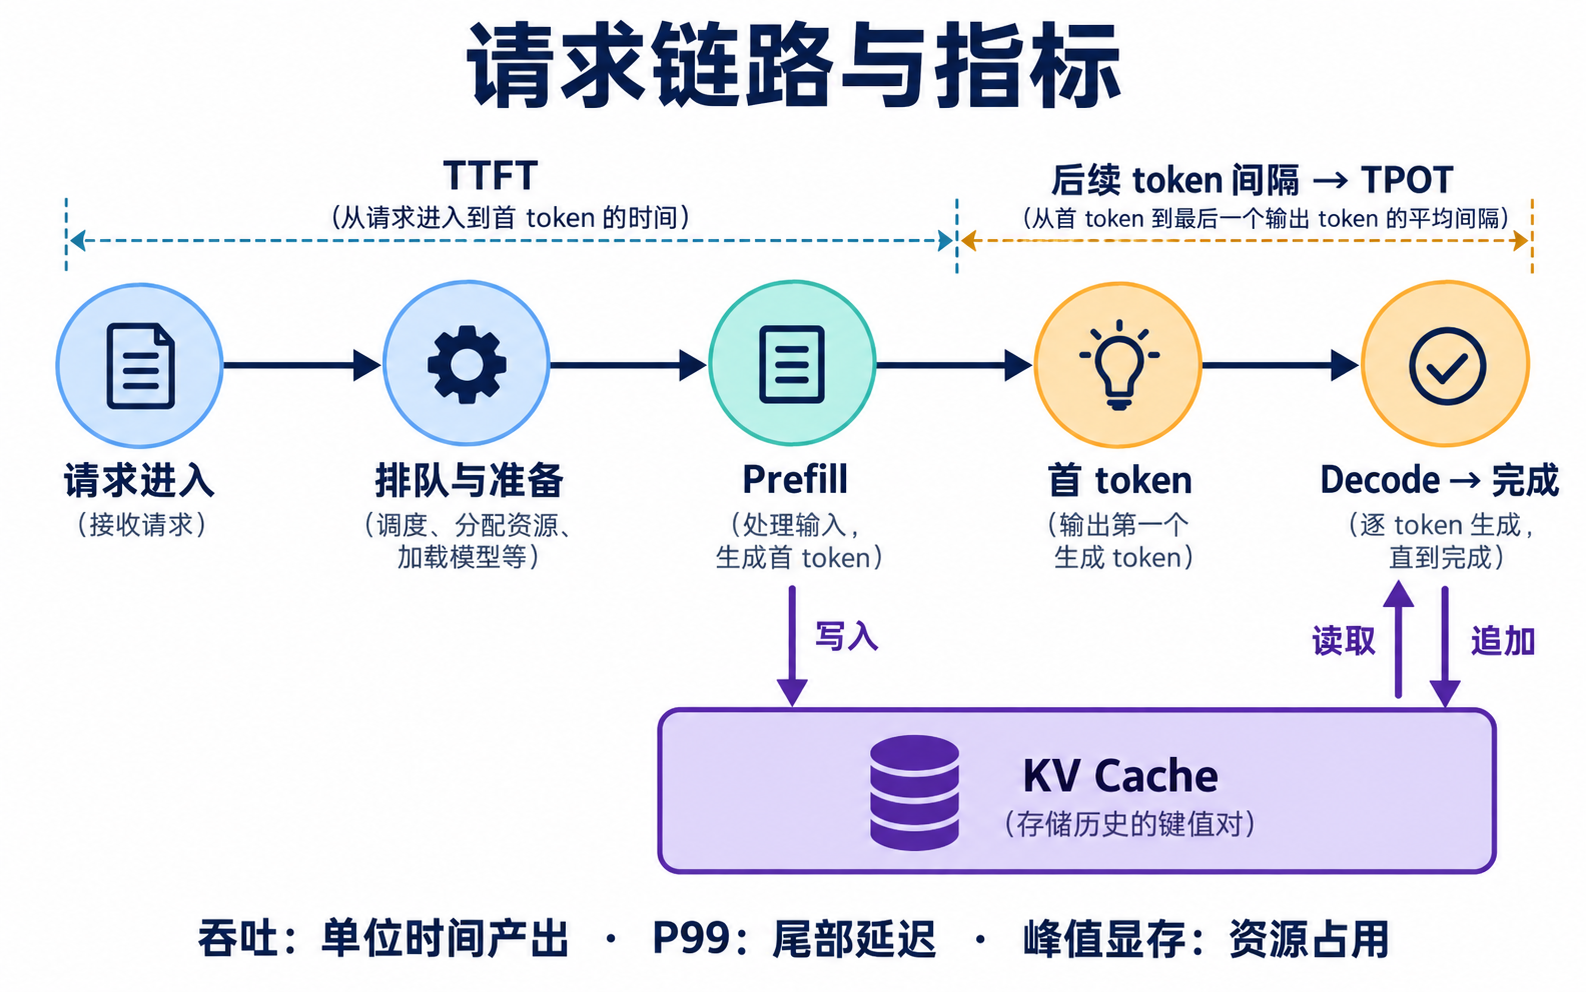

*图 1｜请求路径与指标。KV 是跨阶段状态；图中模型加载只适用于冷启动，热请求应单独计量。TPOT 的严格定义见下方时间戳公式。*

### 1.1 时间戳、阶段耗时与用户延迟

设客户端发出请求时刻为 `t0`，收到首个输出 token 为 `t1`，收到第 N 个输出 token 为 `tN`，收到完成事件为 `t_done`。在本文的客户端口径中：

$$
TTFT=t_1-t_0,\qquad TPOT=\frac{t_N-t_1}{N-1}\quad(N>1)
$$
$$
E2E=t_{done}-t_0,\qquad ITL_i=t_i-t_{i-1}\ (i\ge2)
$$
当 `t_done=tN` 且每个 token 单独可观测时，`E2E = TTFT + (N−1)×TPOT`。完成事件的额外收尾时间应单独解释。N≤1 时 TPOT 不适用，记为缺失值，不能伪造为 0。流式响应若一次发送多个 token，chunk 间隔不等于 token 间隔；服务端 decode 时间也不等于客户端 TPOT。

| 指标 | 回答的问题 | 主要关联 | 口径注意 |
|---|---|---|---|
| TTFT | 首 token 多久可见？ | 排队、输入准备、Prefill、首 token 选择与传输 | 不等于纯 Prefill kernel 时间 |
| TPOT / ITL | 后续生成是否流畅？ | Decode、KV 读取、调度、输出发送 | 请求均值与 token 加权均值不同 |
| Output throughput | 每秒生成多少输出 token？ | batching、生成策略、并发和调度 | 总输出 token / 统一测量窗口秒数 |
| Request throughput | 每秒完成多少请求？ | 请求长度与系统容量 | 不与 token/s 混用 |
| P50 / P95 / P99 | 典型与尾部请求有多慢？ | 队列、负载、抖动 | 必须注明是 TTFT、E2E 还是 ITL 的分位数 |
| Peak memory | 运行时最大显存占用？ | 权重、KV、激活、workspace、分配器 | allocated、reserved、进程显存不能混写 |
| 成功/超时/拒绝/OOM | 服务是否可用？ | 接纳、容量、资源故障 | 不能只平均成功请求而隐去失败 |

分位数要记录样本量和算法；少量 smoke 请求不足以稳定描述 P99。并发数表示同时在途请求数，batch 表示某次执行组织的请求数，两者并不相等。开放式到达流与固定并发的闭环测试也不是同一种压力条件。



### 1.2 每次实验至少保留四层证据

| 证据层 | 记录内容 | 用途 |
|---|---|---|
| 请求条件 | 模型/revision、tokenizer、prompt tokens、实际 generated tokens、batch、concurrency、到达模式、dtype、cache policy | 确认两次测量可比较 |
| 阶段表现 | Prefill/Decode 时间、TTFT、TPOT、ITL | 找到主要阶段 |
| 服务表现 | E2E、吞吐、P50/P95/P99、排队、成功率/拒绝率/超时率 | 判断用户可见收益 |
| 资源表现 | Peak memory、GPU 利用率、Cache 使用量、带宽和通信 | 解释收益来自计算、搬运还是容量 |



### 1.3 workload 决定瓶颈

| 类型 | 典型形态 | 优先指标 | 下一步 |
|---|---|---|---|
| 交互短请求 | 输入与输出都短 | TTFT、P99、超时率 | 队列、Prefill、启动/同步 |
| 长上下文 | 长输入或持续增长历史 | TTFT、Cache、峰值显存 | Attention、Chunked Prefill、KV |
| 批处理 | 可以等待，追求产出 | token/s、成本、完成率 | batch、kernel、量化 |
| 突发并发 | 到达率短时激增 | queue wait、P95/P99、拒绝率 | 接纳控制、调度、扩缩容 |

不能只用平均 Prompt 长度描述 workload；还应保留长度分布、请求顺序、共享前缀、输出长度、停止条件和服务目标。



<a id="chapter-02"></a>

## 02｜GPU、内存层级与 Attention 基础

来源：S25、S27、S22。



### 2.1 先分开“装不下”“搬得慢”“算得慢”

显存容量限制决定是否 OOM；显存带宽限制决定数据能否及时到达计算单元；计算吞吐限制决定运算本身多快。峰值算力不是程序速度。SM 组织线程块与片上资源，warp 是线程执行组织单位；CUDA Core 服务通用计算，Tensor Core 服务受 dtype 和形状条件约束的矩阵乘加。

寄存器 → Shared Memory（片上 SRAM）→ L2 → 全局显存，是观察数据驻留与复用的层次。容量、延迟、带宽和作用域不同，不能用单一数字排序所有代价。连续线程访问连续地址有利于合并访存；寄存器和 shared memory 占用过高可能降低 occupancy。

$$
I=\frac{FLOPs}{Bytes},\qquad P_{roof}=\min(P_{compute}, BW\times I)
$$
Roofline 给出定位假设，不是 profiler 实测；Bytes 必须声明是输入输出理论体积，还是实际 HBM 流量。矩阵乘法 `[m,k]×[k,n]` 的主要 FLOPs 约为 `2mnk`。原资料中的内存带宽代理值、GPU 代际对照仅用于教学，不能当成本机规格。



### 2.2 SRAM 优化的四个联动因素

| 因素 | 希望得到什么 | 可能抵消收益的成本 | S27 小验证 |
|---|---|---|---|
| 数据复用 | 一次搬入、多次使用 | 搬入和同步本身需要时间 | `sram_gain` |
| bank 布局 | 并行访问不同 bank | stride、padding、对齐造成冲突 | `bank_access_report` |
| tile / layout / occupancy | 工作集可驻留且并行度够 | tile 过大占用资源，过小复用不足 | `layout_tile_score` |
| 寄存器预算 | 临时状态留在近处 | spill 重新产生较慢访存 | `spill_tradeoff` |

同一地址的 broadcast 读取不能按“多个不同地址映射同一 bank”的普通冲突计算。教学 score/net_gain 不是真实时间，也不能直接计算 occupancy。



### 2.3 Attention 计算与张量形状

$$
Attention(Q,K,V)=Softmax(QK^\top/\sqrt D+M)V
$$
令 B 为 batch，H 为 Query heads，Hkv 为 KV heads，D 为 head_dim；Sq 为当前 query 长度，Sk 为含历史 Cache 的 key 长度：

| 对象 | 形状 | 说明 |
|---|---|---|
| Q | `[B,H,Sq,D]` | 当前要查询的位置 |
| K / V 与 Cache | `[B,Hkv,Sk,D]` | Cache 保留未扩展的 KV heads |
| score / probability | `[B,H,Sq,Sk]` | Prefill 常有 Sq=Sk，单步 Decode 常有 Sq=1 |
| Attention 输出 | `[B,H,Sq,D]` | 再转置、合并成 `[B,Sq,H×D]` 并做输出投影 |

MHA：Hkv=H；GQA：1<Hkv<H，教学实现要求 H 能被 Hkv 整除；MQA：Hkv=1。RoPE 作用于 Q/K 的位置表示，位置偏移也影响 Cache 兼容性。

实现顺序是 **投影 → reshape/transpose → 在序列维拼接历史 K/V → 对齐 KV head → score/mask → softmax → 聚合 V → 合并 head/输出投影**。必须先保存较少的 KV heads，再临时对齐；否则会失去 GQA 的缓存容量收益。真实 kernel 可以直接处理分组头，不一定物化 `repeat_kv` 的拷贝。

正确性至少检查非法 head 配置、mask 广播、有限输出，以及“全序列最后一个位置”与“前缀 Cache + 单步 Decode”在容差内一致。带历史的多 token 输入要按全局位置构造因果 mask，不能机械使用局部方阵 mask。



<a id="chapter-03"></a>

## 03｜Prefill、FlashAttention 与数据流

来源：S26、S23、S24；基础依赖 S22、S25、S27。



### 3.1 三种优化解决不同问题

| 机制 | 改变什么 | 对照 | 必须观察 |
|---|---|---|---|
| FlashAttention | Attention 中间结果的计算/读写路径 | 标准 Attention vs 分块 Attention | 输出一致性、kernel 时间、工作集/流量、TTFT |
| Chunked Prefill | 长输入进入调度器的粒度 | 完整 Prefill vs chunks | Decode 抖动、TTFT、TPOT、P99 |
| Prefix Cache | 已算过的相同前缀是否重复计算 | cache off vs 命中 | hit_len/reused_tokens、TTFT、Cache 占用 |

Prefill 中，Q/K/V 投影和输出投影带来矩阵计算；score、softmax 与 Value 聚合带来工作集与数据搬运；K/V 在计算中产生并写入 Cache。Cache 写入不是必须等到输出投影之后才发生，流程图表示依赖关系而非严格 kernel 排序。



### 3.2 完整 score 与 tile 工作集

标准非分块 score 的理论元素数为 `B×H×Sq×Sk`；Prefill 等长情形为 `B×H×S²`。单个 score tile 为 `Bq×Bk`；一维 tile 数是 `ceil(S/b)`，二维未考虑 causal 剪枝的 tile 数是其平方。**单 tile 的体积、整个算法总工作量和真实 HBM 流量是三个不同量。**

FlashAttention 避免把完整 score/probability 矩阵反复写回 HBM，仍执行所需的 Attention 计算。tile 越大，循环数可能越少，但寄存器/shared memory 压力越高；tile 越小，片上压力越低，但循环与调度成本增加。不能由工作集压缩倍数直接推出加速倍数。



### 3.3 Online Softmax 的合并公式

对固定的一行 Query，维护最大值 m、指数和 l、**未归一化**加权和 u。新 tile 的分数为 s，值为 Vtile：

$$
m'=\max(m,\max(s)),\qquad a=\exp(m-m'),\qquad p=\exp(s-m')
$$
$$
l'=a l+\sum p,\qquad u'=a u+pV_{tile},\qquad O=u'/l'
$$
初始 `m=−∞, l=0, u=0`。若维护的 O 已归一化，则更新为 `(a×l×O+pVtile)/l'`。不能对每个 tile 独立 softmax 后直接相加，因为归一化分母覆盖整行 Key。

S24 的 CPU 实现采用 Q/K/V 双层分块循环，涵盖 causal、非整除尾块、float64、大 score 稳定性与非法输入；其输入是二维 `[seq_len,dim]`，未实现真实 CUDA/Triton kernel、batch/head、dropout 或 backward。真实累加器可能采用更高精度。推广到任意 mask 时，还要显式处理整行都被屏蔽导致的零分母/非有限状态。



### 3.4 API、dispatch 和服务结果

SDPA 是表达 Attention 的 API；具体 kernel 由设备、dtype、shape、mask、版本等条件决定。调用 SDPA 不足以证明用了 FlashAttention。验证顺序为：**语义正确 → 实际 dispatch 可确认 → kernel 证据可解释 → 请求指标可复测**。

原资料按减少写回、提高并行效率、匹配新硬件介绍 FlashAttention 及后续版本；这些是阅读线索，具体版本能力仍要在目标环境确认。Prefill 优化不能直接推出 Decode TPOT 改善。

| 信号 | 需要检查 | 可探索方向 |
|---|---|---|
| 计算单元接近饱和 | FLOPs、dtype、矩阵形状、Tensor Core 路径 | kernel、融合、精度或形状 |
| 带宽接近上限 | HBM 流量、重复读写和复用 | tiling、FlashAttention |
| kernel 很短但空隙多 | launch、同步、CPU 准备 | 融合、batch、Graph/编译 |
| 长度变化时抖动 | padding、bucket、动态 shape | 分桶与稳定执行形状 |



<a id="chapter-04"></a>

## 04｜Decode、采样与投机式生成

来源：S02、S07、S10、S20。



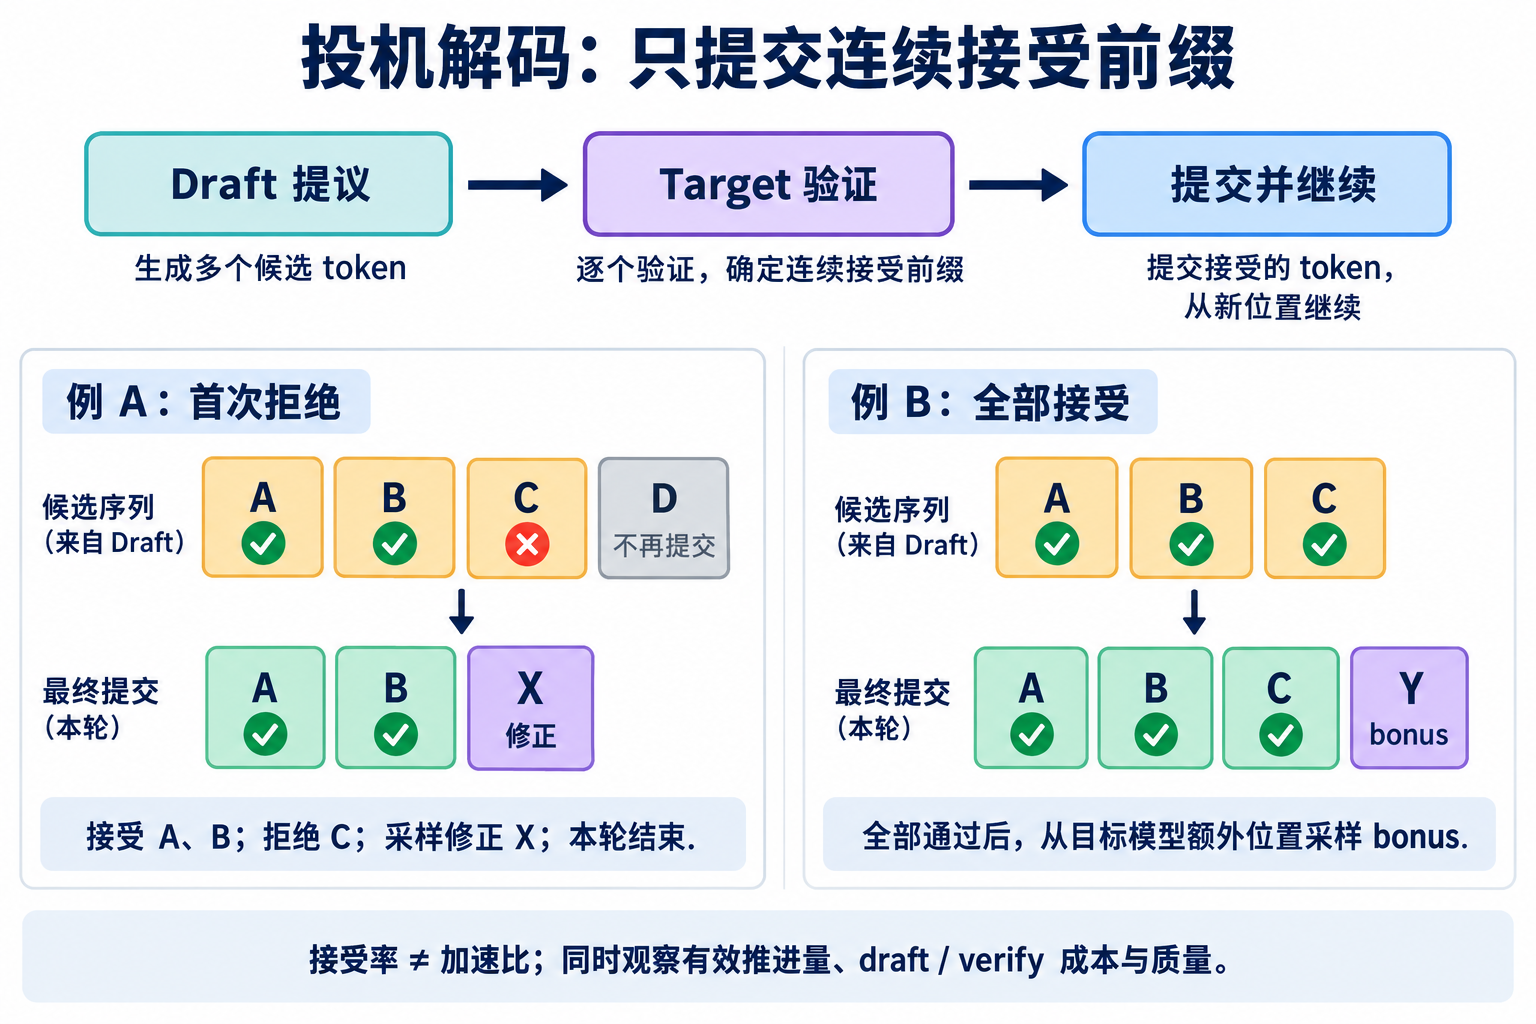

*图 2｜拒绝后修正与全接受后 bonus。图示的是接受判定的先后；target 概率可集中计算，不能据此理解为必须逐个 target forward。*

### 4.1 从 logits 到 token

S07 的顺序是 **Temperature → Top-K → Top-p → Softmax → 选择**。温度要求有限且为正；`logits/T` 改变分布尖锐程度，不改变排序。greedy 使用 argmax，不能把“小但非零温度的采样”当作 greedy。backend 的 `temperature=0` 可是禁用采样的接口约定，不等于把 0 传给本教程的除法函数。

Top-K 以第 K 大分数作阈值时，同分候选可能超过 K。Top-p 在当前候选分布中排序、累计，并保留首次达到/跨过 p 的边界 token；恢复原词表顺序后，候选外设为 `−∞`，重新 softmax。

例：概率 `[0.5,0.3,0.1,0.05,0.05]`，p=0.85 时保留前三个，重归一化分母是 0.9。Top-K 与 Top-p 的先后会改变分布。边界等号的具体实现应记录；不能混用不同实现而声称采样配置完全相同。

生成循环还需要记录 EOS、最大输出长度、停止原因、实际输出 token 数和随机种子。测试关注 shape、dtype/device、非法温度、ties、Top-p 边界、batch、选择与追加循环。



### 4.2 经典 draft/target 投机解码

草稿模型按上下文提出 K 个候选，目标模型对候选路径集中验证。`draft_probs` 为 `[K,Vocab]`，`target_probs` 为 `[K+1,Vocab]`，额外一行提供全部接受时的 bonus。

令 p 为 target、q 为 draft。对于已按 q 采样的候选 x：

$$
\alpha(x)=\min(1,p(x)/q(x))
$$
逐位置接受，首个拒绝后结束本轮，并从修正分布采样：

$$
r(x)=\frac{\max(p(x)-q(x),0)}{\sum_y\max(p(y)-q(y),0)}
$$
全部 K 个候选通过后，从目标模型额外位置采样 bonus token。因此本轮输出是“连续接受前缀 + correction”或“K 个接受 token + bonus”。后续偶然相同的 token 不能跨过首次拒绝继续算接受。实际 EOS/长度预算还可能提前截断。

概率形状、归一化、有限性、非负性与 token 索引必须验证。q(x)=0 的输入边界与 residual 分母也应有明确约定。上述分布保持语义依赖正确的概率对齐、采样和回退；不能拿逐 token 相等检查代替概率验证算法。



### 4.3 从接受率到净收益

$$
acceptance=\frac{accepted}{proposed},\qquad
effective\ progress=\frac{committed\ output\ tokens}{rounds}
$$
`accepted_tokens/rounds` 不包括 correction/bonus，和有效输出推进量不是同一指标。一个粗略盈亏条件是：候选阶段、验证、修正和额外调度的总时间，小于 target-only 生成相同有效输出所需时间；高接受率本身不足以证明加速。

| 分支 | 候选来源 | 必须新增的证据 |
|---|---|---|
| 经典 draft/target | 小模型自回归草稿 | acceptance、target calls、draft/verify cost |
| multi-token / 多头 | 一次多个候选 token 或预测头 | 首拒绝位置、有效推进、验证预算 |
| self-speculative / early exit | 同模型浅层或内部路径 | 草稿代价、恢复/回退语义 |
| tree / multi-candidate | 多条候选路径 | 树验证成本、提交路径、容量 |
| DFlash（原资料扩展） | block diffusion 草稿 | block 长度、接受前缀、draft/verify cost |
| DSpark（原资料扩展） | 半自回归与置信度预算 | confidence、proposal budget、负载下 TPOT |

DFlash/DSpark 的论文与文档链接见原资料 S02，属于原资料中的扩展描述，本次没有独立验证其最新实现。单请求候选预算与服务调度会互相影响：候选变多也可能加重 batch 和验证成本。

S20/68 的 CPU benchmark 是给定 draft/target token 序列上的连续相等前缀模拟，`effective_output_tokens` 由接受与修正组成；它与 S10/23 的概率接受、residual、bonus 教程不是同一算法口径。真实 benchmark 先固定质量，再看吞吐、TTFT/TPOT、接受率、目标调用、draft/verify 代价、回退次数及额外显存。



<a id="chapter-05"></a>

## 05｜KV Cache：表示、分配、复用与治理

来源：S03、S06、S09、S11、S14、S21。



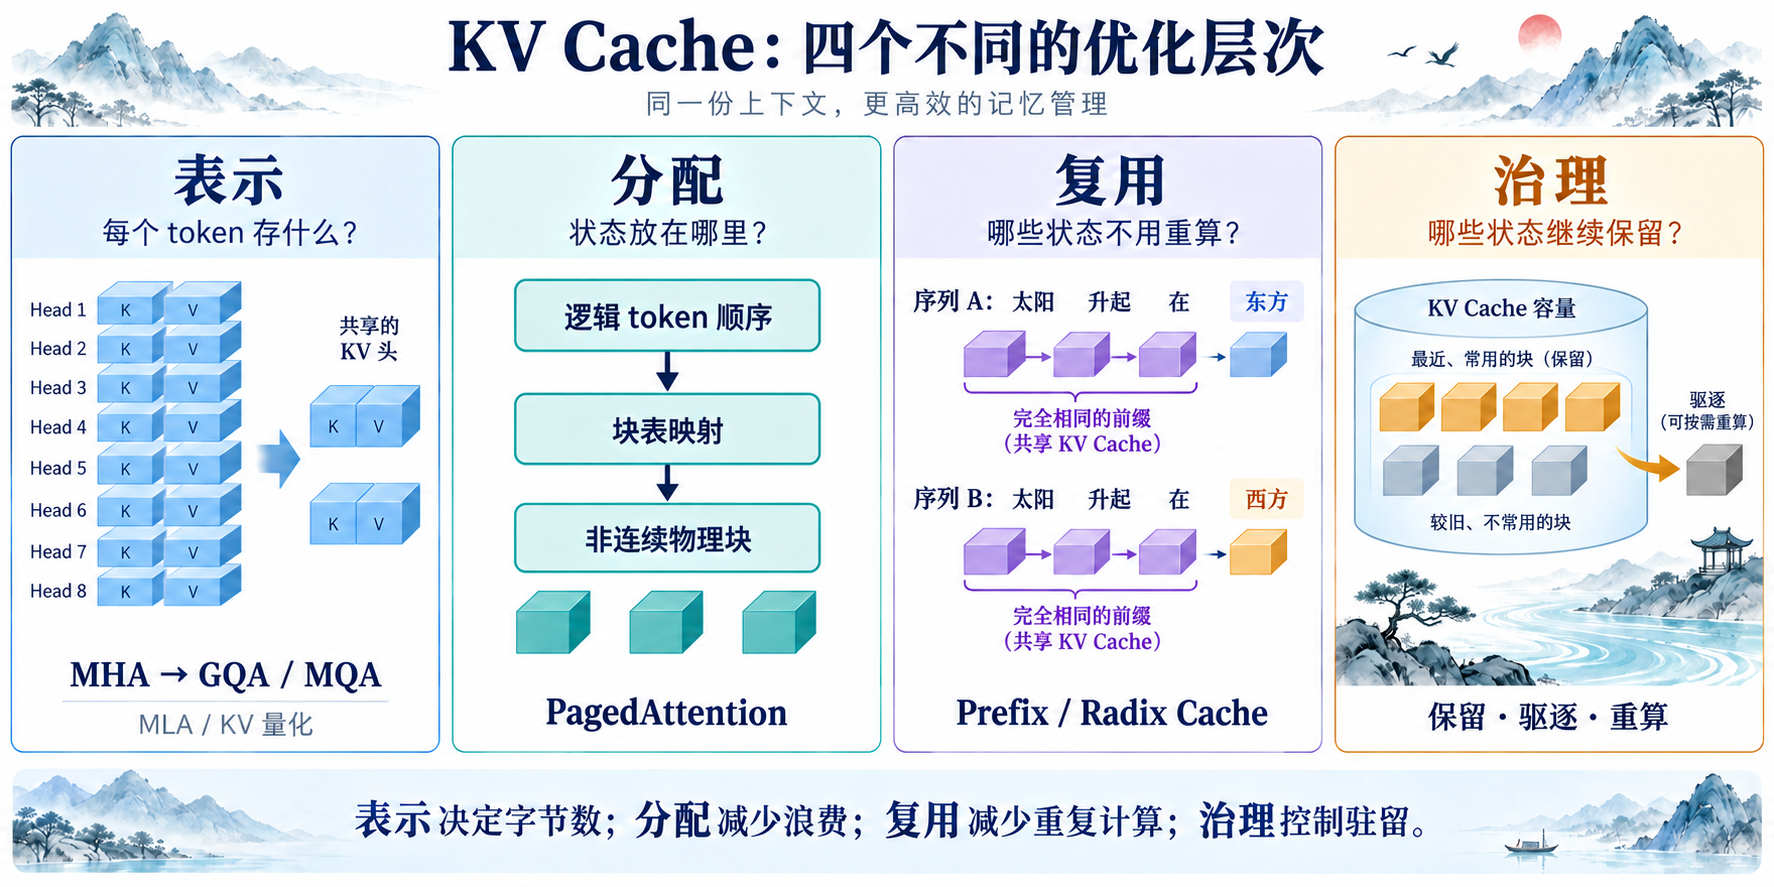

*图 3｜表示、分配、复用与治理。两组共享 KV 是 GQA 示意；MQA 只有一组。文字块只作 token 路径示意，不规定 tokenizer 的实际切分。*

### 5.1 先算清字节账本

对于常规 K/V 等头维、每层形状一致的 Cache：

$$
M_{KV}=2\,L\,B\,H_{kv}\,D\,S\,b
$$
其中 L=层数，B=batch，Hkv=KV heads，D=head_dim，S=缓存 token 数，b=每元素字节数；2 表示 K/V 两份。**S06 的文字公式少了 b，代码已计入 `dtype_bytes`；正文统一使用字节公式。**变长请求应将 B×S 改为各请求实际长度之和；共享页、量化元数据与特殊架构需另算。

例如 L=32、Hkv=8、D=128、b=2，每个 token 的 KV 为 131072 bytes=128 KiB，4096 token、batch=1 为 512 MiB。其余不变时，Hkv=32 为 2 GiB，Hkv=1 为 64 MiB。这些是理论 KV 容量，不是进程 peak memory。

$$
M_{peak}\approx M_{weights}+M_{KV}+M_{activations}+M_{workspace}+M_{allocator/other}
$$
这个加法是容量分解，不代表各项独立峰值可以直接相加；实际 peak 取决于张量生命周期。GB=10⁹ bytes，GiB=2³⁰ bytes，要明确区分。

| 层次 | 改变对象 | 代表机制 | 不应混淆 |
|---|---|---|---|
| 表示 | 每 token 保存或重构的状态 | MHA/GQA/MQA/MLA、KV 量化 | 与分页不是一件事 |
| 分配 | 逻辑状态映射到物理空间 | PagedAttention | 不自动消除每 token 的状态 |
| 复用 | 已有上下文是否重新计算 | Prefix/Radix Cache | 不等于只改变物理布局 |
| 治理 | 状态保留多久、何时回收 | LRU/价值评分、驱逐、重算 | 不等于请求优先级 |

S06 的 MLA `L×B×S×latent_dim×b` 只是潜在表示代理；真实 MLA 可能还需额外位置状态和恢复计算，不能据此宣称完整架构压缩比。



### 5.2 PagedAttention 的账本与原子性

block_size=P 时，长度 S 需要 `ceil(S/P)` 块；分配槽位为 `P×ceil(S/P)`，尾块浪费是分配槽位减 S。第 t 个逻辑 token 位于逻辑块 `t//P`，块内偏移 `t%P`，再通过 block_table 找到物理块。

```text
逻辑 token → 逻辑块号 / 块内偏移 → block_table → 非连续物理 KV 块
Prefill: 初始分配 → Decode: 跨边界扩容 → Finish: 释放 → 新请求复用
```

S09 的关键不变量：空闲池与已分配集合互斥；块索引合法；逻辑长度与块表一致；OOM 不留下半分配；释放不重复；恢复逻辑 Cache 必须按块表顺序，不能按物理地址排序。教学恢复会拼接物理块，真实 kernel 可以直接按映射读取。

通用扩容判断应比较新旧 `ceil(length/P)`。原文解析里的 `new_len % P == 1` 仅适用于特定单 token、P>1 的边界直觉，不是覆盖 P=1 和多 token 追加的通用规则。共享物理页需要引用计数/写时复制等额外语义，不属于此独占块教学管理器。



### 5.3 Radix 匹配与可复用状态

Radix Tree 用压缩边保存 token 路径。插入时计算最长公共前缀，部分重合则分裂成 shared、旧后缀、新后缀，并保留旧分支的子节点、terminal 和缓存指针。匹配返回 `hit_len`，再拆成 `hit_prefix` 与 `miss_suffix`；只有后者需要新增 Prefill。

S11/24 的实现只把有完整 terminal 路径的命中计入可复用长度，**不能把它等同于任意 token 级 LCP 或真实 backend 的全部命中能力**。完整命中后，如何取得下一个 logits、是否需重算末 token，也要看实际 backend。

前缀相同需要是 token 与上下文兼容，而非仅文本看起来相同：模型 revision、tokenizer/特殊 token、位置/RoPE、adapter、量化表示及租户隔离都要确认。采样参数通常不改变已固定 token 前缀的 K/V 本身，但 RNG、生成控制状态和服务缓存键是否兼容要分别检查，不能笼统认为改 temperature 就必然改变 KV。



### 5.4 从完整 block 命中到 LRU

S21/69 只匹配从位置 0 开始的连续完整 block，首个 miss 停止，尾部不足一块不参与。每次写入/访问刷新逻辑时钟，容量超限时驱逐最旧项。

请求命中率 `hit_requests/requests` 与 token 复用率 `reused_tokens/total_prompt_tokens` 不同；复用 token 占比也不等于实际 Prefill 时间下降比例。

**教学实现边界：**S21 的 key 是 `(block_index, block_tokens)`，未编码之前的完整前缀。如果缓存同时出现 A→B 和 C→D，查询 A→D 可能错误拼接不同上下文中的块。实际 KV 复用需要完整前缀身份或父块哈希链及模型/权限命名空间。此模拟只作为教学来源，不能直接部署为真实 Cache。



### 5.5 价值驱逐与生命周期

S14/37 维护 prefix、大小、命中次数、最近访问、当前占用。保留分数由复用奖励、最近访问奖励和容量惩罚组成；`recency=1/(1+time_gap)`。低分优先驱逐，heap 更新留下历史记录，弹出时要与当前 entry 比较并跳过 stale 项。

始终检查 `current_bytes = sum(entry.size)`，拒绝单条超过总容量的状态。评分是教学策略；若实现只在访问/刷新时重算，时间衰减是快照，不是堆中所有项自动连续更新。

| 动作 | 收益 | 代价 | 证据 |
|---|---|---|---|
| 保留 | 后续可复用 | 压低可接纳并发 | 占用、命中率 |
| 驱逐 | 释放容量 | 再次 Prefill | 驱逐、重算 token、TTFT |
| 重算 | 少驻留状态 | 多计算与等待 | recompute 时间 |
| 压缩/量化 | 每 token 字节减少 | 误差与恢复/读写代价 | 字节、质量、kernel、延迟 |

完成、异常取消、版本失效都需要正确清理引用。TTFT 下降不能单独证明命中，必须有 backend metrics、日志或接口返回的命中证据。



<a id="chapter-06"></a>

## 06｜量化：数值映射、对象与部署闭环

来源：S04、S08、S12、S17、S18。



### 6.1 对象、时机、格式分开看

| 路线 | 对象/时机 | 首先验证 | 主要风险 |
|---|---|---|---|
| PTQ | 训练后量化 | 校准、误差和可加载性 | 数据不代表服务分布 |
| QAT | 训练/微调时感知量化误差 | 质量恢复与训练成本 | 数据、时间与算力投入 |
| W8A16 | 8-bit 权重、16-bit 激活 | 存储与前向输出 | 反量化可抵消速度收益 |
| GPTQ / AWQ | 部署前权重校准 | 真实 artifact、loader、kernel | 教学模拟不等于算法实现 |
| FP8 | 权重/激活/计算或 Cache 路径 | 格式、scale、硬件和累加精度 | 8-bit 不代表相同数值语义 |
| KV 量化 | 请求执行时持续保存状态 | 容量、长上下文质量、读取代价 | 误差随服务使用方式体现 |
| GGUF | 文件格式与部署封装 | 匹配 loader/backend，如 llama.cpp | 不是 GPTQ/AWQ 一类算法 |

PTQ 满足质量门槛就先验证部署；PTQ 质量损失过大且有代表性训练数据/预算时，才进一步考虑 QAT。低 bit 不必然更快、更准确或更适合服务。



### 6.2 统一两种 scale 约定

常见步长写法：

$$
q=clip(round(x/\Delta)+z,q_{min},q_{max}),\qquad \hat x=\Delta(q-z)
$$
对称量化 z=0，非对称量化允许零点偏移。S08/S17 使用步长形式；S12/S18 使用其倒数 `s=1/Δ`，即 `q=round(x×s)`、`x_hat=q/s`。二者不能交叉反量化。全零张量要有安全 scale，round/clip 引入表示误差。

per-tensor 元数据少但容易受局部离群值影响；per-channel 适应通道差异；group-wise 在误差与 scale 数量之间折中。分组数向上取整，最后不足一组不能丢失。激活随 token、层和上下文变化，校准输入要覆盖实际场景；原资料还以 SmoothQuant 提醒权重与激活分布协同处理的方向。

7B 参数的理想权重体积：FP16 14 GB、INT8 7 GB、packed INT4 3.5 GB；未计 scale、zero-point、bias、未量化层、临时反量化张量、KV 和分配器。**用 int8 张量保存 4-bit 数值范围仍占 1 byte/元素，不是 packed INT4。**



### 6.3 W8A16 的教学前向

S12 以 `s=127/absmax` 映射，存储范围为 int8；前向把 `weight_int8` 转为激活 dtype，再除以 scale，使用浮点 `F.linear`。bias 也要匹配 dtype。量化权重与 scale 作为 buffer 随状态和设备迁移。

因此这里证明的是低比特**保存**与近似浮点**计算**的关系，不是原生 INT8 GEMM 性能。还原完整浮点权重会产生临时显存。单层权重缩小不等于完整模型 peak 减半。测试包括全零、范围、存储账本、显式反量化参考、FP16/FP32 输出契约。



### 6.4 GPTQ/AWQ：校准统计与教学简化

S17 从输入激活最后一维汇总 RMS 重要性；按输入通道分组，每个输出行/组保存 scale。AWQ 分支挑高重要性通道，用浮点副本保护，其他权重量化；恢复时按组反量化并回填保护位置。

**这里的 `gptq` 分支是分组 absmax 模拟，没有实现完整 GPTQ 的二阶误差补偿；`awq` 分支的浮点保护也不等于真实 AWQ 的完整缩放/搜索与部署算法。**两者的名字用于教学区分，不能把误差对比解释成真实 GPTQ vs AWQ benchmark。保护副本/mask 还会产生额外存储。

可选 GPU 实验从真实模型 q_proj hook 采集激活，但证据仍是 `gpu_simulation_on_real_model_state`。成熟库 artifact 需另测；权重 MSE、校准输出 MSE 不替代任务准确率、格式或工具调用成功率。



### 6.5 FP8 与 KV 分组量化

真实 FP8 的 E4M3/E5M2 在指数范围和尾数精度上不同；并非均匀 int8 量化。S18 的 `FP8KVCacheSim` 实际用 INT8 容器演示 scale 与恢复，不能称为真实 FP8 Tensor Core 测试。

KV 按最后一维分组，保存 q、各组 scale 和原始 shape；恢复必须使用同一位置同一组的 scale。group 更小通常提高局部适应性，但元数据与处理次数增加。真实存储应计 `q bytes + scales bytes + 其他状态`。源实验从 past_key_values 取得真实 KV 后再模拟，证据是 `gpu_simulation_on_real_kv_state`；torchao FP8 weight-only API 探针只测权重路径，不是 KV Cache 证据。



### 6.6 部署验证闭环

**Artifact → loader/backend → 实际 kernel → 固定 workload → 质量与服务决策**。

分别检查数值有限性/shape/logits，生成长度/停止/重复率，目标任务与长上下文质量，最后比较 TTFT、TPOT、吞吐、P99、peak memory。格式加载成功只证明装载可行；显存下降但速度不升时，检查反量化、隐式回退、kernel 和 workload。



<a id="chapter-07"></a>

## 07｜Serving：请求、Cache、批次与资源池

来源：S05、S13、S14、S15、S16、S01。



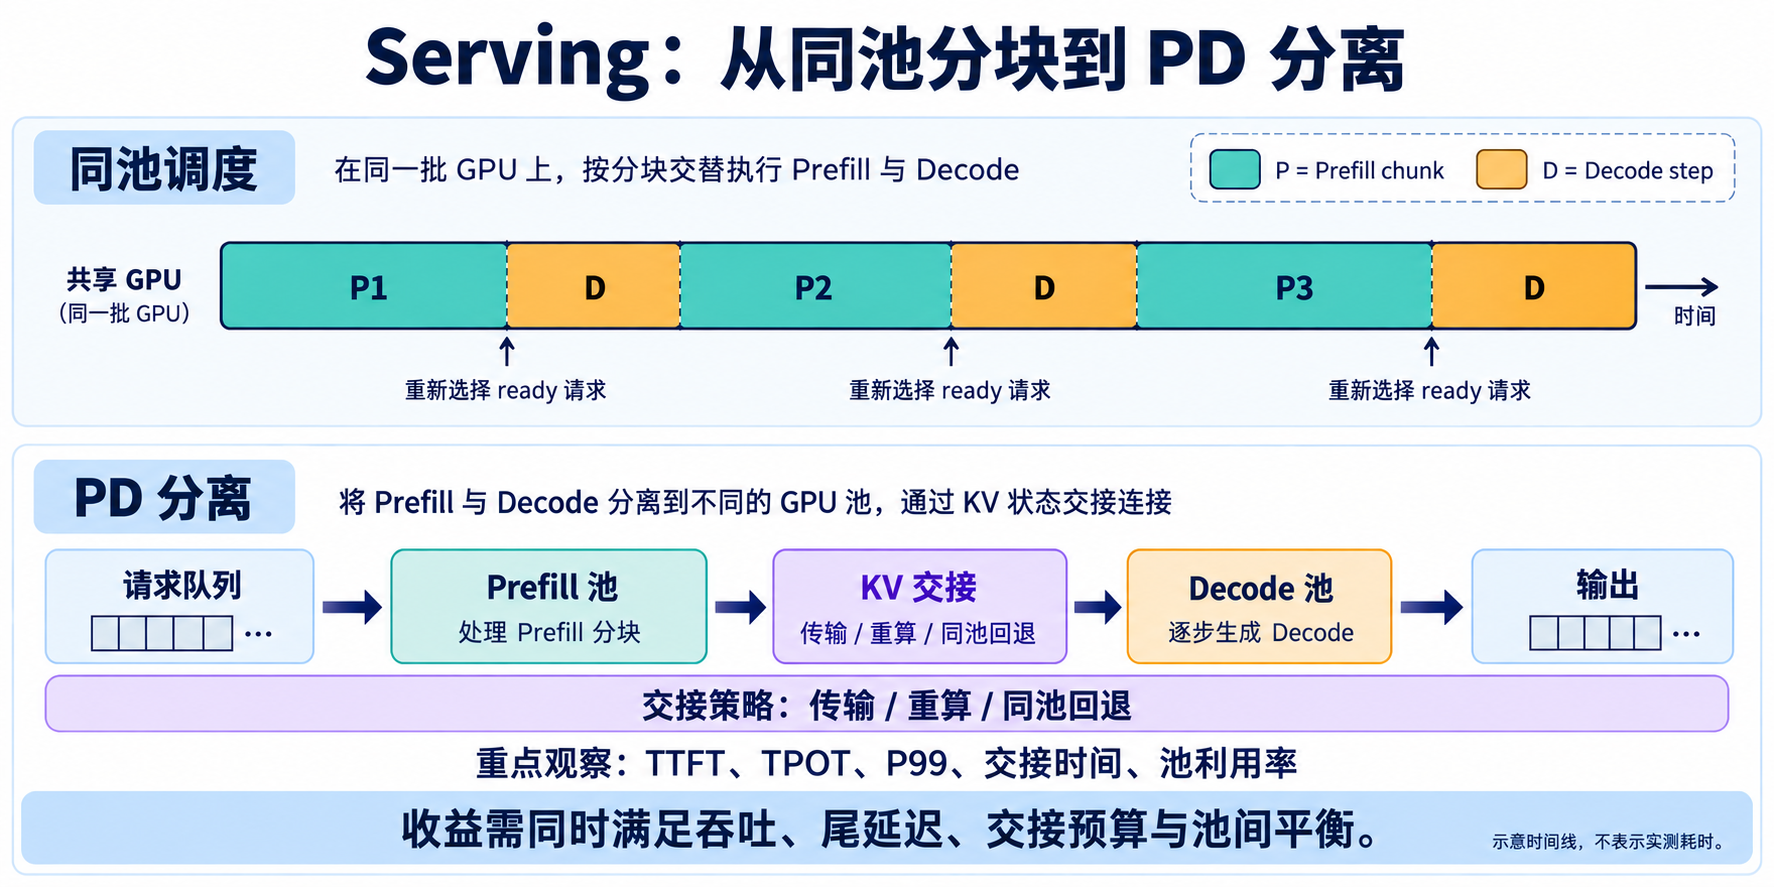

*图 4｜同池分块与 PD 的关系。时间段不按实测比例绘制；同池回退是替代跨池路径，并非跨池传输完成后的必经步骤。*

### 7.1 调度范围逐层扩大

| 层次 | 决策 | 输入 | 结果 |
|---|---|---|---|
| 单步 Decode | 谁得到下一轮推进？ | 阶段、优先级、剩余工作 | 顺序、等待步数、公平性 |
| Cache 资源 | 谁可以驻留/暂停/恢复？ | 空闲容量、块、热度 | 可接纳并发与 OOM 风险 |
| batch/队列 | 哪些 ready 请求组成下一批？ | 到达时间、Prefill/Decode 预算 | 吞吐、queue wait、尾延迟 |
| 服务池 | Prefill/Decode 由谁执行？ | 实例、GPU、服务等级 | 隔离、池利用率、交接 |
| 异构路由扩展 | 传 KV、重算还是同池？ | 状态大小、链路、两池能力、SLO | 路由、回退与成本 |

S05 标题称“四层”，表中另列异构路由扩展；这里明确为四个范围加一个跨池扩展，避免数量表述混乱。vLLM 和 SGLang 都是完整服务 backend，不能把前者限定为分页、后者限定为前缀树；跨 backend 性能差异是服务栈整体结果。



### 7.2 单步请求状态与静态排序的局限

S13/36 的状态是 Prefill → Decode → 完成。入队保存输入长度、生成上限、priority、cache hit；每次只推进选中的一个请求，未选中的活动请求累计 wait_steps。

排序键为 `(phase_rank, cache_rank, -priority, total_len, request_id)`，教程中 Prefill 优先、cache hit 优先，其余字段逐级稳定打破平局。该规则可用于观察顺序，但不保证生产公平性：持续到来的高优先级/Prefill 请求可能压住其他请求。`max_steps` 是循环保护，不是公平机制；wait_steps 不是毫秒。



### 7.3 Continuous Batching 与 Chunked Prefill

Continuous Batching 在迭代边界重新查看 ready 集合，允许完成请求退出、新请求加入。Chunked Prefill 只切分未命中 suffix，保持顺序与尾块，并在 chunk 边界给其他 Decode 请求准入机会。

小 chunk 提高让出频率，但可能增加调度/launch 代价；大 chunk 有利于一次处理更多计算，但可能伤害 Decode 流畅度。它与 Prefix Cache 互补：前者决定**怎样处理剩余工作**，后者决定**剩余工作有多少**。



### 7.4 PD 与异构交接

长输入短生成倾向 Prefill 压力，短输入长生成倾向 Decode/KV 压力，两者都长是混合压力。S15 的逻辑分池要求每个请求只进入一个计划池，不能遗漏或重复；逻辑账本本身不证明真实 worker 已拆开。

S15 的教学决策要求吞吐提高、P95 不恶化且 handoff 在预算内；实际服务还要同时看质量、失败、P99、资源成本和池利用率。S16 将选择扩展为：

| 方案 | 何时有意义 | 需要付出/验证 |
|---|---|---|
| 传输 KV | 状态兼容且链路足够快 | transfer bytes、handoff、拥塞与等待 |
| 重算 Prefill | 传输太慢或状态不兼容 | 目标池的额外计算与队列 |
| 保持同池 | 隔离收益小于交接成本 | 原池竞争与尾延迟 |

用十进制 MB 与 Gbit/s，理想传输毫秒数为 `8×MB/Gbit_s`；若带宽是 GB/s，则是 `MB/GB_s`。S16 表头的 GB/s 与代码参数 `link_gbps` 有单位混写风险，使用时以明确的 bit/byte 单位为准。真实交接还包含固定延迟、序列化、布局、同步及链路竞争，不能只用大小/带宽定结论。

服务动作先保护可运行性：显存压力时回退同池或限制接纳；handoff 超预算时比较重算；队列超 SLO 时路由、限流或扩容。每次动作保留触发信号、原因和实际结果。



### 7.5 关键路径、I/O 与重叠

```text
CPU 准备 ─────┐
              GPU Prefill ─ KV handoff ─ GPU Decode ─ 输出
下一批 CPU 准备 ────────────┘（有依赖约束的可重叠区间）
```

重叠降低的是关键路径中的暴露等待，不是让各项耗时凭空消失。CPU 双线程、GPU 双流、流水线、DBO 类批次拆分都要证明 overlap 与 idle gap 的变化；并行增加争用或同步也可能更慢。

| 时间位置 | 证据字段 | 解读边界 |
|---|---|---|
| 进入 | queue_wait_ms、input_transfer_bytes/ms | 排队不是 GPU 计算 |
| 执行/输出 | idle_gap、overlap_ratio、stream_output_ms | 定义分母并核对时间线 |
| KV 交接 | transfer_bytes、handoff_ms、recompute_ms | 传输/重算是备选路径，不能重复计入 |
| 网络/通信 | network_wait_ms、communication_ms、exposed_comm_ms | 总通信时间与暴露通信时间不同 |
| 启动 | model_load_ms、cold_start | 不混入热请求平均 |
| 资源池 | Prefill/Decode 利用率、P95/P99 | 一池加速可能让另一池等待 |

接纳控制包括排队、限流/拒绝、允许范围内降级、转移/扩容；必须观察队列长度、拒绝率、超时率、质量和迁移代价。



### 7.6 多卡与 MoE 的扩展边界

Tensor/ Pipeline/ Expert Parallel 加入分片、同步、负载均衡与通信。MoE 总参数量不等于每 token 实际激活计算量，要记录 Router 选择的专家数、expert load、capacity factor、token dispatch 和通信空转。

PCIe、NVLink、NVSwitch 的成本取决于实际设备/拓扑。源资料的链路代理不模拟 All-Reduce/All-Gather 的完整算法与通信量。多 GPU、79–81、自动扩缩容是来源中的后续阅读方向，不是本批已提供的完整课程。



<a id="chapter-08"></a>

## 08｜把四项 Benchmark 接成一个实验闭环

来源：S19/66、S20/68、S21/69、S01/70。



### 8.1 四个项目的分工

| 项目 | CPU 机制 | G0 | G1 | G2 / 扩展 | 关键门槛 |
|---|---|---|---|---|---|
| 66 综合基线 | 请求波次、瓶颈分类、决策 | 固定浮点 backend 基线 | 只改并发/batch/dtype/cache/backend 之一 | 已验证组合、SGLang 对照 | 目标服务指标、质量与失败 |
| 68 投机 | 连续接受、候选排序、质量优先 | target-only | draft+target | proposal length/draft family/budget 中一项 | acceptance、推进、target calls、draft/verify cost |
| 69 前缀缓存 | 完整块连续命中、LRU、候选选择 | cache off | 同条件 prefix cache | 一项缓存配置或 backend | 直接命中证据、TTFT、维护成本 |
| 70 调度 | ready batch、状态推进、多指标决策 | concurrency=1 | 增加负载 | 同负载下受控路由/PD 策略 artifact | queue、P99、公平性、池/交接证据 |

各 Notebook 的 G0/G1/G2 命名是局部实验组，含义并不统一。特别是 70 的 G0→G1 是负载扫描，不能据此宣称“调度策略优化成功”；需要同负载下真实受控的 G2。



### 8.2 CPU 模型与真实实验分开

66 按 `[start,end)` 波次覆盖全部请求，保留最后不足 concurrency 的尾波；显存压力优先分类，其次 Prefill/Decode 占比，再 balanced。同步波次模型不是生产 continuous batching。

70 从已到达 pending 中选不超过 batch_size 的 ready 请求，FIFO/shortest/priority 都保留稳定 tie-breaker。active batch 的教学时间是批内最长 service_ms 除以 batch_speedup，不能相加；完成请求只记录一次。queue wait 被用作首 token 前排队代理，不能当作完整真实 TTFT；fairness/utilization 也是特定模型定义。

| 证据类型 | 可以证明 | 不能直接证明 |
|---|---|---|
| CPU 公式/模拟 | 状态、边界、概率、容量守恒 | GPU 延迟/吞吐 |
| environment_preflight / dry_run | 配置与环境可检查 | 策略实际生效 |
| synthetic_gpu_* | 合成张量或人工负载行为 | 真实模型/服务收益 |
| 真实模型状态上的模拟 | 层/KV 的字节、局部误差、处理时间 | 完整 GPTQ/AWQ/FP8 kernel 或部署 |
| real backend smoke | 小规模服务可运行与初步现象 | 稳定 P99、全面质量和泛化结论 |
| 固定 workload 重复服务实验 | 当前硬件/版本/负载下的服务表现 | 任意模型、硬件或请求分布 |



### 8.3 六步测量协议

1. **固定实验契约**：模型/revision、tokenizer、adapter、backend/version、硬件/驱动/runtime、实际 dtype；请求文件/顺序/到达模式、实际 token 长度、生成与停止设置、cache policy。
2. **预检与基线**：确认配置、依赖、端口和资源；区分 Notebook client 与独立 backend 环境。预热、冷/热状态、测量窗口和重复次数预先确定。
3. **改变一个主要变量**：不同 backend 的比较须承认改变了整个服务栈；避免同时更换模型、长度、dtype 后归因单一机制。
4. **采集原始证据**：请求级时间戳、阶段/队列、成功与失败，机制日志、资源统计；GPU 时间须正确同步，服务端显存不能用仅客户端进程统计代替。
5. **保存独立 JSON 与 manifest**：记录分组、artifact、quality、failure、evidence_level、decision、retest_path；缺失指标用 null/未采集，不能填 0 或代理值。
6. **按目标决策**：质量或可运行性失败则 reject/回退；证据缺失或收益有代价则 tune/补测；同口径、质量与资源/尾延迟均达标才 accept，并保留适用范围。

负的 `candidate−baseline` 延迟差表示改善，正的吞吐差表示改善；吞吐增益比例是 `candidate/baseline−1`，不是原始差值。失败样本单独报告，不与成功运行混合平均，也不能删除后只呈现收益。



### 8.4 原资料中的历史案例：吞吐与交互体验的取舍

以下是 S19 的**历史 smoke 记录**，非本次运行：Qwen2.5-0.5B-Instruct，RTX 5070 Ti Laptop 12 GB，vLLM 0.11.0，BF16，fixed.jsonl，最大生成长度 64，`max_model_len=2048`、显存利用率配置 0.8、`--enforce-eager`。

| 指标 | concurrency=1 | concurrency=4 |
|---|---:|---:|
| 成功/失败 | 5/0 | 5/0 |
| 请求吞吐 req/s | 3.1189 | 4.2972 |
| 输出吞吐 token/s | 182.1461 | 250.9544 |
| TTFT P50 ms | 33.776 | 234.566 |
| TPOT P50 ms/token | 4.859 | 11.528 |
| E2E P50 ms | 337.176 | 956.383 |
| peak memory | 未采集 | 未采集 |

吞吐提高约 37.8%，TTFT P50 约为原来的 6.94 倍；对批处理可能有价值，对交互请求则需看 SLO。只有 5 个请求，不足以稳定推断尾部；未采集显存，不能得出显存改善结论。来源区分 client PyTorch 2.11.0+cu128 与独立 backend PyTorch 2.8.0+cu128；环境摘要不能把两者混成同一个执行环境。



### 8.5 各机制缺一不可的证据

| 候选 | 只有这个数字还不够 | 还需提供 |
|---|---|---|
| FlashAttention | TTFT 下降 | 实际 kernel、语义一致、工作集/时间 |
| 投机解码 | acceptance 高 | 有效输出、draft/verify 成本、目标调用、质量 |
| Prefix Cache | TTFT 下降 | backend hit/reused tokens 与来源、驱逐/占用 |
| 量化 | 文件变小或能加载 | kernel、运行显存、速度、任务质量 |
| PD | throughput 上升 | 同资源同负载、handoff、池平衡、P99 |
| 调度 | GPU 利用率升高 | 等待、完成率、公平性、P99 与策略生效日志 |



<a id="chapter-09"></a>

## 09｜统一诊断路线与复习题

| 观察现象 | 优先假设 | 下一项最小证据 | 阅读位置 |
|---|---|---|---|
| Prompt 越长 TTFT 越高 | Prefill/Attention 成本 | 阶段耗时与 dispatch | 02–03 |
| TTFT 高但 Prefill 占比低 | 排队/输入/批次准备 | queue 与时间戳 | 01、07 |
| TPOT 高、Decode 占比大 | KV 读取/计算/调度 | Cache 长度、kernel、队列 | 04–05、07 |
| 候选多但吞吐不升 | draft/verify 开销过大 | 每轮提交与成本 | 04、08 |
| 权重装不下 | 权重驻留 | 完整内存账本、loader | 06 |
| 上下文/并发增长导致 OOM | KV 容量 | 每 token 字节、页利用率 | 05–06 |
| 重复前缀无收益 | 未命中或维护成本 | hit/reused/eviction | 05、08 |
| 突发负载 P99 恶化 | 排队/接纳/公平性 | 到达流、queue、失败 | 07–08 |
| PD 吞吐升、P99 降不下来 | 交接暴露或池不平衡 | handoff/recompute/池利用率 | 07 |
| 无单点瓶颈 | 多项串行/重叠成本 | 端到端时间线与单变量对照 | 08 |

容量受限与带宽受限都常被笼统叫 memory-bound，但行动不同：前者先算能否装下，后者先看要搬多少与实际带宽。

复习时应能独立回答：

1. KV 为什么不是 Prefill 后的独立阶段？TTFT 为什么不等于 Prefill 时间？
2. GQA、FlashAttention、PagedAttention、Prefix Cache、KV 量化分别改变哪个对象？
3. Online Softmax 为什么必须重标定旧的分母和输出？
4. Top-p 边界、Top-K 同分、temperature=0 的接口约定分别有什么风险？
5. 投机拒绝后为何不能继续接受后面的相同 token？bonus 与 correction 有何区别？
6. 块表 OOM 时应保持哪些状态不变？为何 `(位置,当前块)` 不足以唯一标识真实 KV？
7. 权重 MSE 小为什么仍需要任务质量回归？W8A16 教学前向为何可能省存储却不加速？
8. 分池为何可能提高吞吐却伤害 P99？应选择传输、重算还是同池？
9. 70 的负载扫描为何不能当作策略对照？只有 TTFT 变化能否证明 Prefix Cache 命中？
10. 历史 smoke、CPU 模拟、真实 backend 重复实验分别允许得出多强的结论？



<a id="chapter-10"></a>

## 10｜校注与使用方式

正文统一了 KV 字节公式的 dtype 因子、Prefill/Decode 的 Sq/Sk、两种 scale 的倒数关系、Gbit/s 与 GB/s，并区分 INT4/FP8 容器模拟、GPTQ/AWQ 教学简化、CPU 指标代理和真实 backend 证据。

配图是整理时新生成的机制示意，已内嵌 Notebook；同时提供独立 PNG。原资料中未随附件提供的图片没有复刻为原图。

下方最小自检只验证时间口径、KV 字节、分页边界与前缀身份反例，不启动模型或服务。来源索引只保留编号和名称，用于理解正文中的 S01–S28 引用。


<a id="selfcheck"></a>

## 最小可运行自检

仅使用 Python 标准库；下方输出是本次实际自检结果，不是 GPU benchmark。

In [1]:
from math import isfinite

def request_metrics(start_ms, token_ms):
    if not isfinite(start_ms) or not token_ms or any(not isfinite(x) for x in token_ms):
        raise ValueError("需要有限的开始时刻和非空 token 时间戳")
    if token_ms[0] < start_ms or any(b < a for a, b in zip(token_ms, token_ms[1:])):
        raise ValueError("时间戳必须按非递减顺序排列，且不早于请求")
    return {"ttft_ms": token_ms[0] - start_ms,
            "e2e_to_last_token_ms": token_ms[-1] - start_ms,
            "tpot_ms": (token_ms[-1] - token_ms[0]) / (len(token_ms)-1) if len(token_ms)>1 else None}

def kv_bytes(layers, kv_heads, head_dim, lengths, dtype_bytes=2):
    if any(type(x) is not int or x <= 0 for x in (layers, kv_heads, head_dim, dtype_bytes)):
        raise ValueError("模型维度与 dtype_bytes 必须为正整数")
    if any(type(x) is not int or x < 0 for x in lengths):
        raise ValueError("请求长度必须为非负整数")
    return 2 * layers * kv_heads * head_dim * sum(lengths) * dtype_bytes

def block_growth(old_len, new_len, block_size):
    if any(type(x) is not int for x in (old_len, new_len, block_size)) or not (0 <= old_len <= new_len and block_size > 0):
        raise ValueError("需要整数长度、new>=old>=0 和正 block_size")
    return (new_len + block_size-1)//block_size - (old_len+block_size-1)//block_size

def demo():
    metrics = request_metrics(0, [100, 120, 140, 160])
    assert metrics == {"ttft_ms": 100, "e2e_to_last_token_ms": 160, "tpot_ms": 20}
    assert request_metrics(0, [100])["tpot_ms"] is None
    try:
        request_metrics(0, [2, 1])
    except ValueError:
        pass
    else:
        raise AssertionError("未拒绝逆序时间戳")
    assert kv_bytes(32, 8, 128, [4096]) == 512 * 1024**2
    assert kv_bytes(32, 32, 128, [4096]) == 4 * kv_bytes(32, 8, 128, [4096])
    assert block_growth(0, 1, 1) == 1  # block_size=1 的边界
    assert block_growth(15, 17, 16) == 1
    assert block_growth(16, 16, 16) == 0
    # (块位置, 当前块) 会把不同历史混在一起：AB 与 CD 不应允许复用 AD。
    paths = [("A", "B"), ("C", "D")]
    weak_keys = {(i, block) for path in paths for i, block in enumerate(path)}
    query = ("A", "D")
    assert all((i, block) in weak_keys for i, block in enumerate(query))
    full_prefix_keys = {path[:i+1] for path in paths for i in range(len(path))}
    assert query not in full_prefix_keys
    print("PASS：时间口径、单 token 边界、KV 字节、分页边界、前缀上下文反例")

demo()


PASS：时间口径、单 token 边界、KV 字节、分页边界、前缀上下文反例


<a id="source-index"></a>

## 来源名称索引

仅作引用说明，不包含原件内容。

| 编号 | 来源名称 |
|---|---|
| <a id="S01"></a>S01 | 70_Serving_Scheduler_Benchmark.ipynb |
| <a id="S02"></a>S02 | 03_decoding_strategies.md |
| <a id="S03"></a>S03 | 04_kv_cache_lifecycle_and_reuse.md |
| <a id="S04"></a>S04 | 05_quantized_inference_and_deployment.md |
| <a id="S05"></a>S05 | 07_serving_scheduling_and_pd.md |
| <a id="S06"></a>S06 | 11_KV_Cache_and_Memory_Growth.ipynb |
| <a id="S07"></a>S07 | 21_Decoding_Strategies.ipynb |
| <a id="S08"></a>S08 | 21_Quantization_Theory_and_INT4_INT8.ipynb |
| <a id="S09"></a>S09 | 22_vLLM_PagedAttention.ipynb |
| <a id="S10"></a>S10 | 23_Speculative_Decoding.ipynb |
| <a id="S11"></a>S11 | 24_SGLang_RadixAttention.ipynb |
| <a id="S12"></a>S12 | 25_Quantization_W8A16.ipynb |
| <a id="S13"></a>S13 | 36_Decode_Scheduling.ipynb |
| <a id="S14"></a>S14 | 37_KV_Cache_Scheduling.ipynb |
| <a id="S15"></a>S15 | 38_Prefill_Decode_Scheduling.ipynb |
| <a id="S16"></a>S16 | 39_Hetero_PD_and_Serving_Tiers.ipynb |
| <a id="S17"></a>S17 | 40_GPTQ_and_AWQ_Weight_Quantization.ipynb |
| <a id="S18"></a>S18 | 41_FP8_and_KV_Cache_Quantization.ipynb |
| <a id="S19"></a>S19 | 66_Inference_Performance_Comparison.ipynb |
| <a id="S20"></a>S20 | 68_Speculative_Decoding_Benchmark.ipynb |
| <a id="S21"></a>S21 | 69_Prefix_Caching_Benchmark.ipynb |
| <a id="S22"></a>S22 | 04_Attention_MHA_GQA.ipynb |
| <a id="S23"></a>S23 | 14_FlashAttention_Memory_Model.ipynb |
| <a id="S24"></a>S24 | 20_FlashAttention_Sim.ipynb |
| <a id="S25"></a>S25 | 03_GPU_Architecture_and_Memory.ipynb |
| <a id="S26"></a>S26 | 02_prefill_and_attention_kernel.md |
| <a id="S27"></a>S27 | 24_SRAM_Optimization_Techniques.ipynb |
| <a id="S28"></a>S28 | 01_request_path_and_metrics.md |